In [ ]:
import pandas as pd
import scanpy as sc
import os
import re
import numpy as np
import json
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.cluster.hierarchy import dendrogram, linkage
import scipy.cluster.hierarchy as shc
from sklearn.cluster import AgglomerativeClustering
from scipy.stats import entropy


mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# Not gzip-compatible; example in jupyterlab script
def load_vcf(file):
    if os.path.exists(file):
        
        # Load VCF results
        exclude = [i for i, line in enumerate(open(file)) if line.startswith('##')]
        if len(exclude)>0:
            skip_rows = max(exclude)+1
        else:
            skip_rows = None

        vcf = pd.read_csv(
            file,
            skiprows = skip_rows,
            sep = '\t')

        return vcf

def extract_feature(adata, feature):

    ad_subset = adata[:, adata.var['feature_types']==feature]

    obs_names = adata.obs.index.tolist()
    var_names = ad_subset.var_names
    array = ad_subset.X.toarray()

    df = pd.DataFrame(
        array,
        index=obs_names,
        columns=var_names
    )

    return df

def merge_granular_states(df, level_state, index_list=None):
    new_state_df = []
    for state in set(annotation_hierarchy[level_state]):
            cts_to_merge = annotation_hierarchy[annotation_hierarchy[level_state]==state]['annotation_granular'].tolist()
            cts_to_merge = [i for i in cts_to_merge if i in df.columns]
            if len(cts_to_merge)>0:
                if index_list is not None:
                    indices = [i for i in index_list if i in df.columns]
                    df = df.set_index(indices)
                col = df[cts_to_merge].sum(axis=1)
                col.name = state
                new_state_df.append(col)
    new_state_df = pd.concat(new_state_df, axis=1, ignore_index=False)
    return new_state_df

In [ ]:
visium_dir = '../../../data/GBM_LEAP_annotations/web_atlas/anndata/'
visium_files = os.listdir(visium_dir)
visium_files = [i for i in visium_files if 'h5ad' in i]

registration=False

## This code is horrifyingly bad; rewrite if given the opportunity 
slides = {}
for visium_file in visium_files:
    
    # load cell2loc adata and merge ROI metadata
    adata = sc.read_h5ad(visium_dir+visium_file)
    adata.obs['barcode'] = [re.sub('_.*$', '', i) for i in adata.obs.index.tolist()]
    slides[visium_file] = adata

/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/annd

In [ ]:
st_data = pd.read_csv('../../../data/visium_annotated_ST.csv', index_col=0)

In [ ]:
all_clones = [str(i) for i in range(11) if str(i) in st_data.columns]+['diploid']

In [ ]:
st_data = st_data[all_clones]
st_data['sample'] = [re.sub('^.*GBM_(.*?)_GR.*$', 'GBM_\\1', i) for i in st_data.index]
st_data['sample'] = [re.sub('^.*GBM_(.*?)-GR.*$', 'GBM_\\1', i) for i in st_data['sample']]
st_data['barcode'] = [re.sub('^.*2020-A_', '', i) for i in st_data.index]
st_data.index = st_data['barcode']+'_'+st_data['sample']

In [ ]:
global_summary = []
for file in visium_files:   
    # rework indices;
    slides[file].obs.index = [re.sub('space.*_GBM_(.*?)_GR.*$', 
                                     'GBM_\\1', i) for i in slides[file].obs.index]

    st_df = slides[file].obs
    st_df = st_df.reset_index().merge(
        st_data[all_clones].reset_index(), on = 'index', 
        how = 'left').set_index('index')

    clone_entropy = st_df[all_clones].apply(entropy, axis=1)
    clone_entropy_normalised = clone_entropy/np.log(len(st_df.columns))

    if 'diploid' in st_df.columns:
        maligant_prob = 1-st_df['diploid']
    else:
        maligant_prob = 1

    # get niche info
    sn_df = extract_feature(slides[file], 'Spatial niche abundances')
    
    st_df = st_df.reset_index().merge(sn_df.reset_index(), on = 'index', how = 'left').set_index('index')
    
    st_df['clone_entropy'] = clone_entropy
    st_df['clone_entropy_normalised'] = clone_entropy_normalised
    st_df['maligant_prob'] = maligant_prob

    global_summary.append(st_df)
global_summary = pd.concat(global_summary)

In [ ]:
# originally done by taking idxmax of niche id
niches = ['Pial layer', 'Immune (TAMs)',
       'Proliferative', 'Dev-like (AC)', 'Grey matter', 'Gliosis transition',
       'White matter', 'Hypoxic 1 (niche)', 'Gliosis', 'Vasculature',
       'Immune (resident)', 'Gliosis (diffuse)', 'Hypoxic 2 (niche)',
       'Dev-like (OPC)', 'Dev-like (Neuron)', 'Astrocyte rich']

# only use niches very representative of the biology (apply filter)
global_summary_niches = global_summary.copy()
global_summary_niches['top_niche'] = global_summary_niches[niches].idxmax(axis=1)
global_summary_niches['global_summary_max'] = global_summary_niches[niches].divide(
    global_summary_niches[niches].sum(axis=1), axis=0).max(axis=1)

global_summary_niches = global_summary_niches[global_summary_niches['global_summary_max']>0.8]

In [ ]:
order = global_summary_niches.groupby('top_niche')['maligant_prob'].mean().sort_values().index.tolist()

/tmp/ipykernel_3328740/2883825244.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=global_summary_niches, y="maligant_prob", x="top_niche",
/tmp/ipykernel_3328740/2883825244.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(axes.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_3328740/2883825244.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


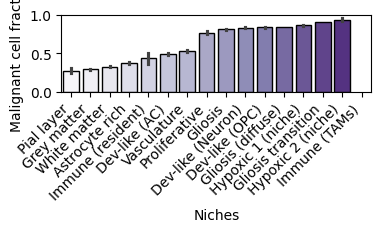

In [ ]:
fig, axes = plt.subplots(1, figsize=(4, 1))
sns.barplot(data=global_summary_niches, y="maligant_prob", x="top_niche", 
            order=order, palette= "Purples", edgecolor="black", ax=axes)
axes.set_ylabel("Malignant cell fraction")
axes.set_xlabel("Niches")  # Remove the duplicate y-axis label
axes.set_xticklabels(axes.get_xticklabels(), rotation=45, ha="right")
axes.set_ylim(0, 1)
# Adjust layout
plt.tight_layout()

# Save the figure
plt.show()

In [ ]:
len(set(st_data['sample']))

92

In [ ]:
missing = [i for i in set(global_summary['sample']) if i not in set(st_data['sample'])]

In [ ]:
global_summary['sample'] = [re.sub('^.*GBM_(.*?)_GR.*$', 'GBM_\\1', i) for i in global_summary['sample']]
global_summary['sample'] = [re.sub('^.*GBM_(.*?)-GR.*$', 'GBM_\\1', i) for i in global_summary['sample']]


In [ ]:
set(global_summary[global_summary['sample'].isin(missing)]['sample_name'])

{'AT12-BRA-4-FO-4_1',
 'AT13-BRA-3-FO-2_1',
 'AT13-BRA-3-FO-2_2',
 'AT13-BRA-3-FO-4_2',
 'AT15-BRA-4-FO-A2-S21',
 'AT15-BRA-4-FO-F1-S18'}